In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from scvi.external import RESOLVI

from sklearn.cluster import KMeans

/home/nathanlevy/mambaforge/envs/resolvi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import scanpy as sc
import scvi
import anndata as ad
import numpy as np
import pandas as pd
from rich import print

import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Optional

from scvi.external import RESOLVI


scvi.settings.seed = 34


@dataclass(frozen=True)
class PARAMS:
    "set all params for our analysis"

    # DATA_FOLDER: str = (
    #     "/home/labs/nyosef/Collaboration/SpatialDatasets/xenium/human_breast_cancer/"
    # )
    DATA_FOLDER: str = "/home/nathanlevy/sda/Data/"
    DATA_FILE: str = "xenium_breast_cancer_S1_R1_2.h5ad"
    DATA_FILE_PROSEG: str = "proseg_resolvi_scanvi_xenium_breast_cancer_S1_R1_2.h5ad"

    FIGURES_FOLDER: str = "figures/"

    # for the data
    COORDS: str = "spatial"
    BATCH: str = "sample"
    SAMPLE: str = "sample"
    CELL_TYPE: str = "predictions_resolvi_proseg_coarse"
    NICHE: str = "kmeans_alpha_5"

    N_EPOCHS = 100
    BATCH_SIZE = 1024


setup = PARAMS()

adata_proseg = sc.read_h5ad(setup.DATA_FOLDER + setup.DATA_FILE_PROSEG)
# adata_proseg.obsm["spatial"] = adata_proseg.obs[["x", "y"]].values
# adata_proseg.write_h5ad("proseg_xenium_breast_cancer_S1_R1_2.h5ad")

print(adata_proseg)
# adata_orig = sc.read_h5ad(setup.DATA_FOLDER + setup.DATA_FILE_PROSEG)

Global seed set to 34


AnnData object with n_obs × n_vars = 278658 × 313
    obs: 'sample', '_scvi_batch', 'cell_type', '_scvi_labels', 'batch', 'predictions_scanvi', 'x', 'y', 'z', 
'observed_x', 'observed_y', 'observed_z', 'fov', 'probability', 'background', 'confusion', 'n_counts', '_indices', 
'_scvi_ind_x', 'predicted_celltype_resolvi', 'predicted_celltype_prob_resolvi', 'predictions_resolvi_proseg', 
'predictions_resolvi_proseg_coarse', 'predicted_celltype_resolvi_coarse', 'index', 'kmeans_alpha_4', 
'kmeans_alpha_5'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'pca'
    obsm: 'X_pca', 'X_resolvi', 'X_resolvi_MDE', 'X_resolvi_proseg', 'X_scANVI', 'X_scANVI_MDE', 'X_spatial', 
'celltype_transfer_resolvi', 'distance_neighbor', 'index_neighbor', 'niche_composition', 'niche_distances', 
'niche_indexes', 'observed_spatial', 'spatial'
    varm: 'PCs'
    layers: 'counts', 'counts_wo_bg'

In [4]:
adata_proseg.obs["predicted_celltype_resolvi"].value_counts()

predicted_celltype_resolvi
Stromal                    66083
Invasive_Tumor             51556
CD4+_T_Cells               21924
Macrophages_1              20505
DCIS_1                     20434
CD8+_T_Cells               17303
DCIS_2                     17044
Endothelial                15644
B_Cells                    11749
Myoepi_ACTA2+              11199
Prolif_Invasive_Tumor       6986
Myoepi_KRT15+               5679
Macrophages_2               5368
Unlabeled                   2623
Perivascular-Like           2221
IRF7+_DCs                    986
LAMP3+_DCs                   516
Mast_Cells                   479
Stromal_&_T_Cell_Hybrid      232
T_Cell_&_Tumor_Hybrid        127
Name: count, dtype: int64

In [5]:
adata_proseg.obs["predictions_resolvi_proseg"].value_counts()

predictions_resolvi_proseg
Stromal                    66998
Invasive_Tumor             49322
DCIS_1                     24231
Macrophages_1              20839
CD4+_T_Cells               20307
CD8+_T_Cells               19080
Endothelial                16054
DCIS_2                     13080
B_Cells                    11976
Myoepi_ACTA2+              11525
Prolif_Invasive_Tumor       8483
Myoepi_KRT15+               5560
Macrophages_2               5349
Perivascular-Like           2123
Unlabeled                   1669
IRF7+_DCs                    999
LAMP3+_DCs                   515
Mast_Cells                   437
Stromal_&_T_Cell_Hybrid       64
T_Cell_&_Tumor_Hybrid         47
Name: count, dtype: int64

In [6]:
coarse_categories_proseg = adata_proseg.obs["predictions_resolvi_proseg"].astype(str)


coarse_categories_proseg[coarse_categories_proseg.isin(["DCIS_1", "DCIS_2"])] = "DCIS"
coarse_categories_proseg[
    coarse_categories_proseg.isin(["Prolif_Invasive_Tumor", "Invasive_Tumor"])
] = "Invasive_Tumor"


adata_proseg.obs["predictions_resolvi_proseg_coarse"] = coarse_categories_proseg.astype(
    "category"
)

In [7]:
coarse_categories = adata_proseg.obs["predicted_celltype_resolvi"].astype(str)

coarse_categories[coarse_categories.isin(["DCIS_1", "DCIS_2"])] = "DCIS"
coarse_categories[
    coarse_categories.isin(["Prolif_Invasive_Tumor", "Invasive_Tumor"])
] = "Invasive_Tumor"

adata_proseg.obs["predicted_celltype_resolvi_coarse"] = coarse_categories.astype(
    "category"
)

In [31]:
import pandas as pd

# typing_1 = "predictions_scanvi_coarse"
typing_1 = "predictions_resolvi_proseg_coarse"
typing_2 = "predicted_celltype_resolvi_coarse"

# Filter the DataFrame for rows where the predictions differ
df_filtered = adata_proseg.obs[
    [
        typing_1,
        typing_2,
        "predicted_celltype_prob_resolvi",
    ]
]
disagrement = adata_proseg.obs[typing_1] != adata_proseg.obs[typing_2]

# Group by the categories in predictions_scanvi and count the occurrences in predicted_celltype_resolvi
grouped_counts = (
    df_filtered.groupby([typing_1, typing_2]).size().reset_index(name="count")
)

# Convert the result to a pivot table for better readability
pivot_table = grouped_counts.pivot_table(
    index=typing_1,
    columns=typing_2,
    values="count",
    fill_value=0,
)

# Print the result
pivot_table

/tmp/ipykernel_2878582/3356223993.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby([typing_1, typing_2]).size().reset_index(name="count")
/tmp/ipykernel_2878582/3356223993.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = grouped_counts.pivot_table(


predicted_celltype_resolvi_coarse,B_Cells,CD4+_T_Cells,CD8+_T_Cells,DCIS,Endothelial,IRF7+_DCs,Invasive_Tumor,LAMP3+_DCs,Macrophages_1,Macrophages_2,Mast_Cells,Myoepi_ACTA2+,Myoepi_KRT15+,Perivascular-Like,Stromal,Stromal_&_T_Cell_Hybrid,T_Cell_&_Tumor_Hybrid,Unlabeled
predictions_resolvi_proseg_coarse,,,,,,,,,,,,,,,,,,
B_Cells,11539.0,34.0,6.0,1.0,2.0,12.0,10.0,19.0,47.0,8.0,0.0,0.0,1.0,2.0,267.0,0.0,0.0,28.0
CD4+_T_Cells,19.0,19914.0,171.0,3.0,1.0,1.0,6.0,10.0,38.0,2.0,4.0,0.0,3.0,0.0,11.0,27.0,9.0,88.0
CD8+_T_Cells,5.0,1635.0,17029.0,3.0,1.0,0.0,6.0,0.0,69.0,1.0,1.0,12.0,1.0,0.0,139.0,32.0,60.0,86.0
DCIS,0.0,3.0,0.0,36358.0,1.0,1.0,821.0,1.0,12.0,0.0,0.0,42.0,39.0,0.0,5.0,0.0,0.0,28.0
Endothelial,0.0,2.0,0.0,1.0,15501.0,0.0,16.0,0.0,8.0,7.0,0.0,3.0,4.0,157.0,324.0,0.0,0.0,31.0
IRF7+_DCs,15.0,2.0,0.0,0.0,0.0,952.0,0.0,1.0,6.0,4.0,0.0,0.0,0.0,0.0,18.0,0.0,0.0,1.0
Invasive_Tumor,10.0,1.0,1.0,464.0,1.0,1.0,57235.0,3.0,7.0,2.0,4.0,5.0,6.0,0.0,15.0,0.0,5.0,45.0
LAMP3+_DCs,14.0,3.0,0.0,0.0,0.0,2.0,0.0,476.0,10.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,4.0
Macrophages_1,16.0,74.0,20.0,40.0,1.0,4.0,53.0,3.0,19902.0,259.0,2.0,14.0,5.0,0.0,289.0,0.0,2.0,155.0


In [32]:
adata_proseg.obsm[RESOLVI_LATENT_KEY + "_MDE"] = scvi.model.utils.mde(
    adata_proseg.obsm[RESOLVI_LATENT_KEY]
)

In [42]:
"CD8" in adata_proseg.var_names

False

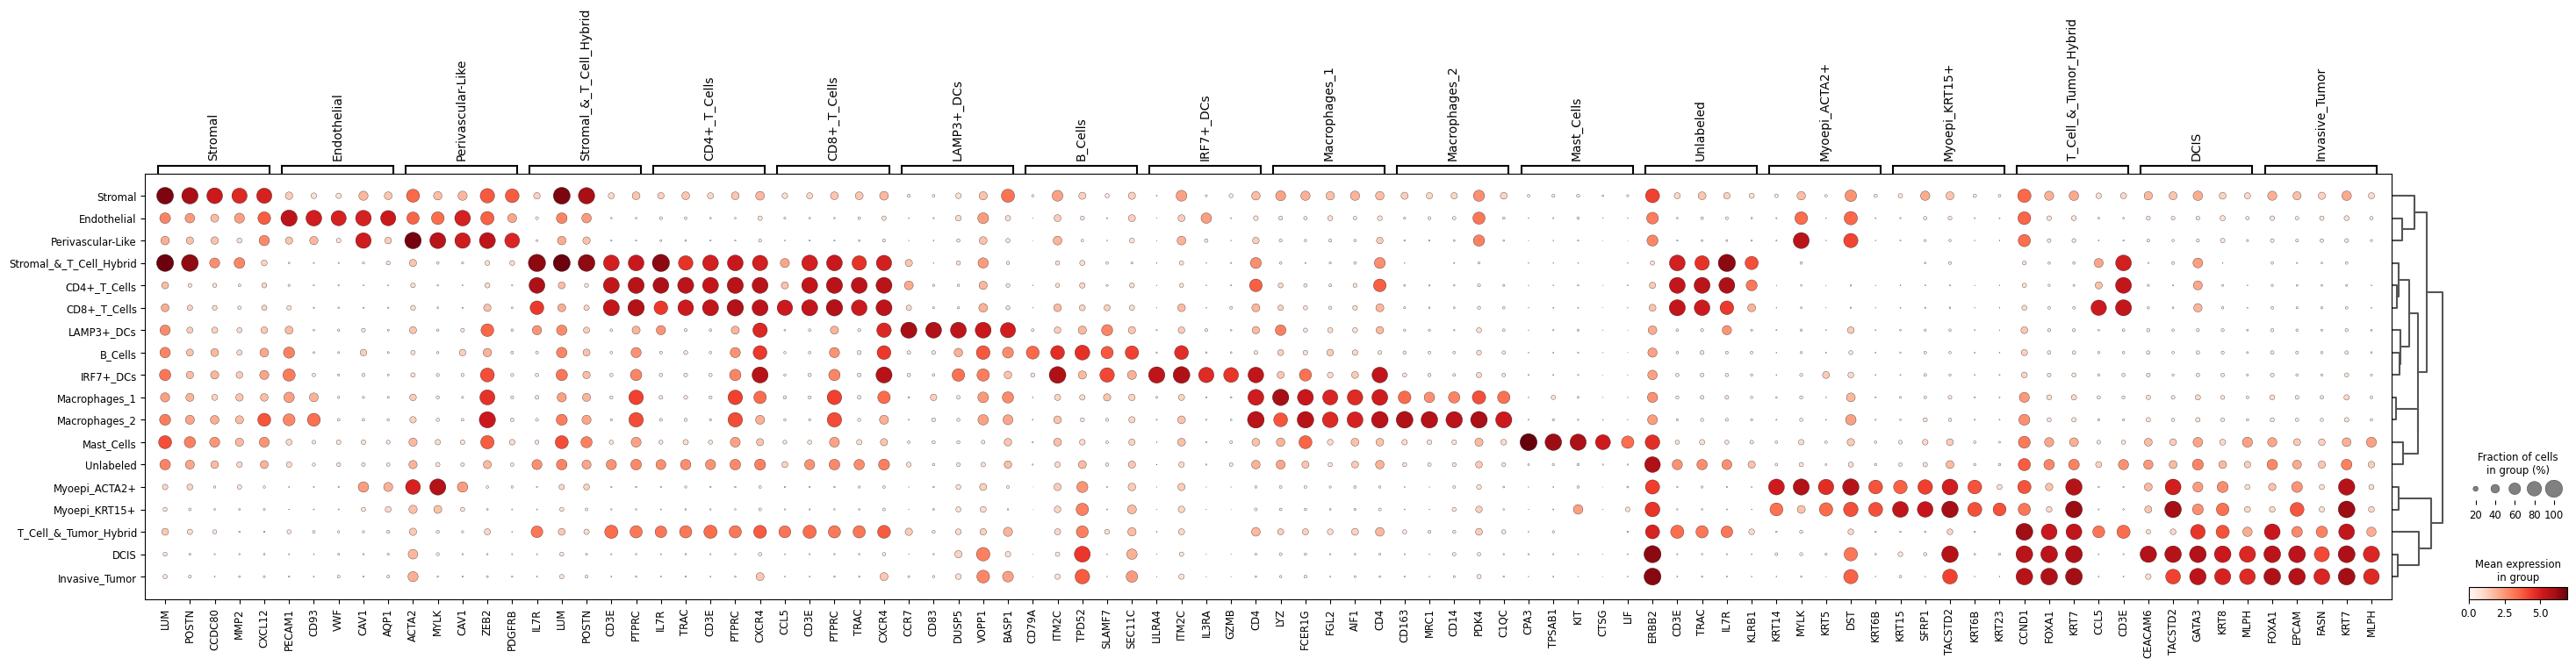

In [45]:
sc.tl.rank_genes_groups(
    adata_proseg,
    groupby=typing_1,
    method="wilcoxon",
    key_added="rank_genes_groups_wilcoxon_cell_type",
    use_raw=False,
    pts=True,
    n_genes=None,
)

sc.pl.rank_genes_groups_dotplot(
    adata_proseg,
    groupby=typing_1,
    standard_scale=None,
    n_genes=5,
    key="rank_genes_groups_wilcoxon_cell_type",
)

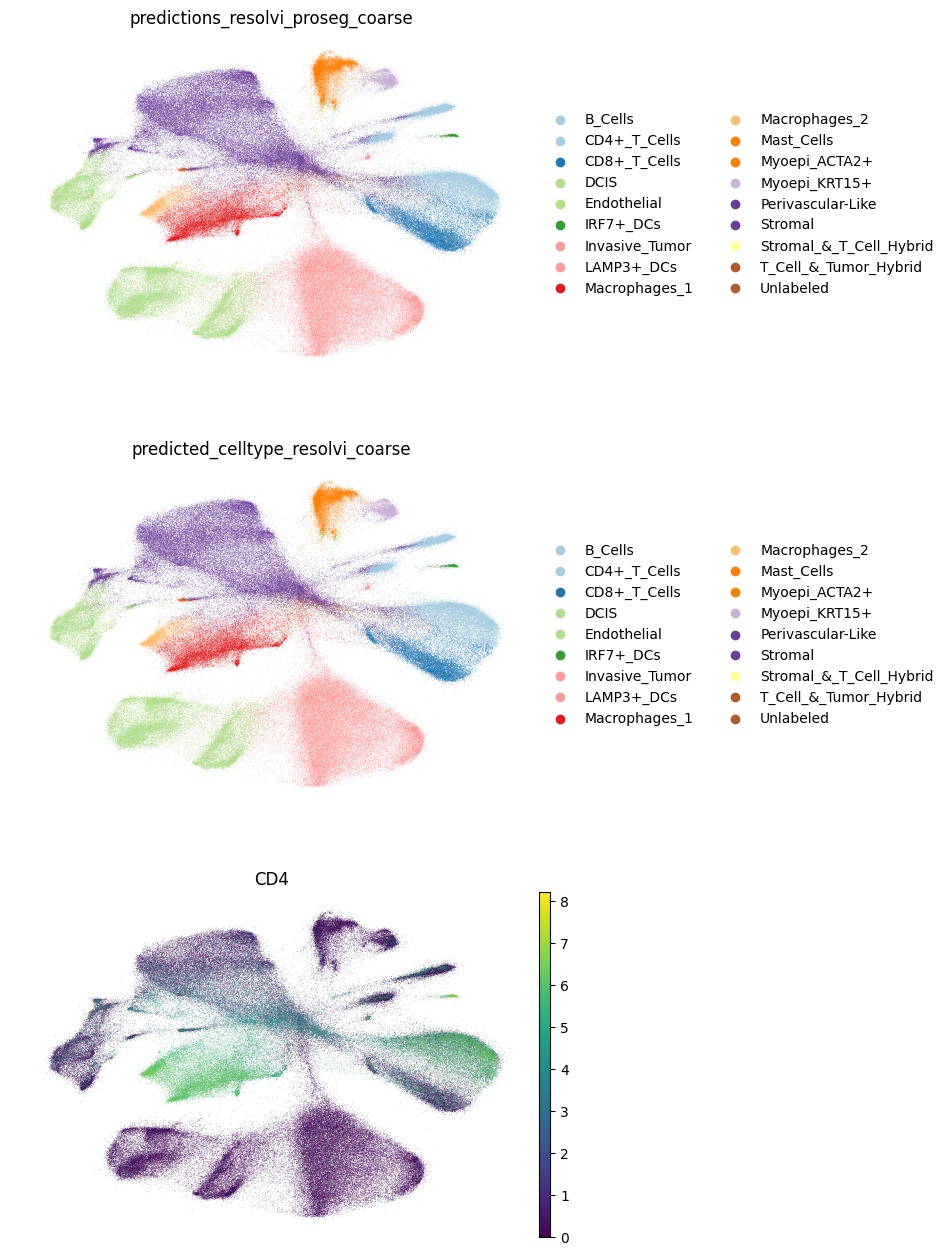

In [47]:
RESOLVI_LATENT_KEY = "X_resolvi_proseg"
CMAP = "Paired"


sc.pl.embedding(
    # adata_proseg[disagrement],
    adata_proseg,
    basis=RESOLVI_LATENT_KEY + "_MDE",
    # color=[setup.CELL_TYPE],
    color=[
        typing_1,
        typing_2,
        "CD4",
        # "predicted_celltype_prob_resolvi",
        # "batch",
    ],
    frameon=False,
    ncols=1,
    palette=CMAP,
    show=True,
)

In [46]:
adata_proseg.write_h5ad(setup.DATA_FOLDER + setup.DATA_FILE_PROSEG)

In [49]:
def get_niche_indexes(
    adata,
    sample_key: str,
    niche_indexes_key: str,
    cell_coordinates_key: str,
    k_nn: int,
    niche_distances_key: str | None = None,
):
    from sklearn.neighbors import NearestNeighbors

    adata.obsm[niche_indexes_key] = np.zeros((adata.shape[0], k_nn), dtype=int)
    adata.obsm[niche_distances_key] = np.zeros((adata.n_obs, k_nn))

    adata.obs["index"] = np.arange(adata.shape[0])
    # build a dictionnary giving the index of each 'donor_slice' observation:
    donor_slice_index = {}
    for sample in adata.obs[sample_key].unique():
        donor_slice_index[sample] = adata.obs[adata.obs[sample_key] == sample][
            "index"
        ].values

    for sample in adata.obs[sample_key].unique():
        sample_coord = adata.obsm[cell_coordinates_key][adata.obs[sample_key] == sample]

        # pynndescent is not faster than sklearn.neighbors.NearestNeighbors in such low dimensions (2D space)
        # neigh_output = pynndescent(
        #     X=sample_coord, n_neighbors=k_nn + 1, random_state=0, n_jobs=-1
        # )
        # indices, distances = neigh_output.indices, neigh_output.distances

        # Create a NearestNeighbors object
        knn = NearestNeighbors(n_neighbors=k_nn + 1)

        # Fit the kNN model to the points
        knn.fit(sample_coord)

        # Find the indices of the kNN for each point
        distances, indices = knn.kneighbors(sample_coord)

        # Store the indices in the adata object
        sample_global_index = donor_slice_index[sample][indices].astype(int)

        adata.obsm[niche_indexes_key][adata.obs[sample_key] == sample] = (
            sample_global_index[:, 1:]
        )

        adata.obsm[niche_indexes_key] = adata.obsm[niche_indexes_key].astype(int)

        adata.obsm[niche_distances_key][adata.obs[sample_key] == sample] = distances[
            :, 1:
        ]

    print(
        "[bold cyan]Saved niche_indexes and niche_distances in adata.obsm[/bold cyan]"
    )

    return None


def get_neighborhood_composition(
    adata,
    cell_type_column: str,
    indices_key: str = "niche_indexes",
    niche_composition_key: str = "niche_composition",
):
    indices = adata.obsm[indices_key].astype(int)

    cell_types = adata.obs[cell_type_column].unique().tolist()
    cell_type_to_int = {cell_types[i]: i for i in range(len(cell_types))}

    # Transform the query vector into an integer-valued vector
    integer_vector = np.vectorize(cell_type_to_int.get)(adata.obs[cell_type_column])

    n_cells = adata.n_obs
    # For each cell, get the cell types of its neighbors
    cell_types_in_the_neighborhood = [
        integer_vector[indices[cell, :]] for cell in range(n_cells)
    ]

    # Compute the composition of each neighborhood
    composition = np.array(
        [
            np.bincount(
                cell_types_in_the_neighborhood[cell],
                minlength=len(cell_type_to_int),
            )
            for cell in range(n_cells)
        ]
    )

    # Normalize the composition of each neighborhood
    composition = composition / indices.shape[1]
    composition = np.array(composition)

    neighborhood_composition_df = pd.DataFrame(
        data=composition,
        columns=cell_types,
        index=adata.obs_names,
    )

    adata.obsm[niche_composition_key] = neighborhood_composition_df

    print("[bold green]Saved niche_composition in adata.obsm[/bold green]")

    return None


get_niche_indexes(
    adata_proseg,
    setup.SAMPLE,
    "niche_indexes",
    setup.COORDS,
    k_nn=20,
    niche_distances_key="niche_distances",
)
get_neighborhood_composition(adata_proseg, setup.CELL_TYPE)

Saved niche_indexes and niche_distances in adata.obsm

Saved niche_composition in adata.obsm

In [50]:
k_list = [4, 5]

X = adata_proseg.obsm["niche_composition"]

# make the data standard normal

# X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

for k in k_list:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto").fit(X)
    adata_proseg.obs["kmeans_alpha_" + str(k)] = kmeans.labels_


cluster_to_niche = {
    0: "DCIS 1 tumor niche",
    1: "Peri-tumor area",
    2: "Intact tissue, stromal area",
    3: "Invasive tumor niche",
    4: "DCIS 2 tumor niche",
}

cluster_to_niche = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    # 4: "4",
}


cluster_to_niche = {
    2: "DCIS tumor niche",
    4: "Peri-tumor area",
    3: "Peri-tumor area",
    0: "Intact tissue, stromal area",
    1: "Invasive tumor niche",
}


adata_proseg.obs[setup.NICHE] = adata_proseg.obs["kmeans_alpha_5"].map(cluster_to_niche)

/home/nathanlevy/mambaforge/envs/resolvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


/home/nathanlevy/mambaforge/envs/resolvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


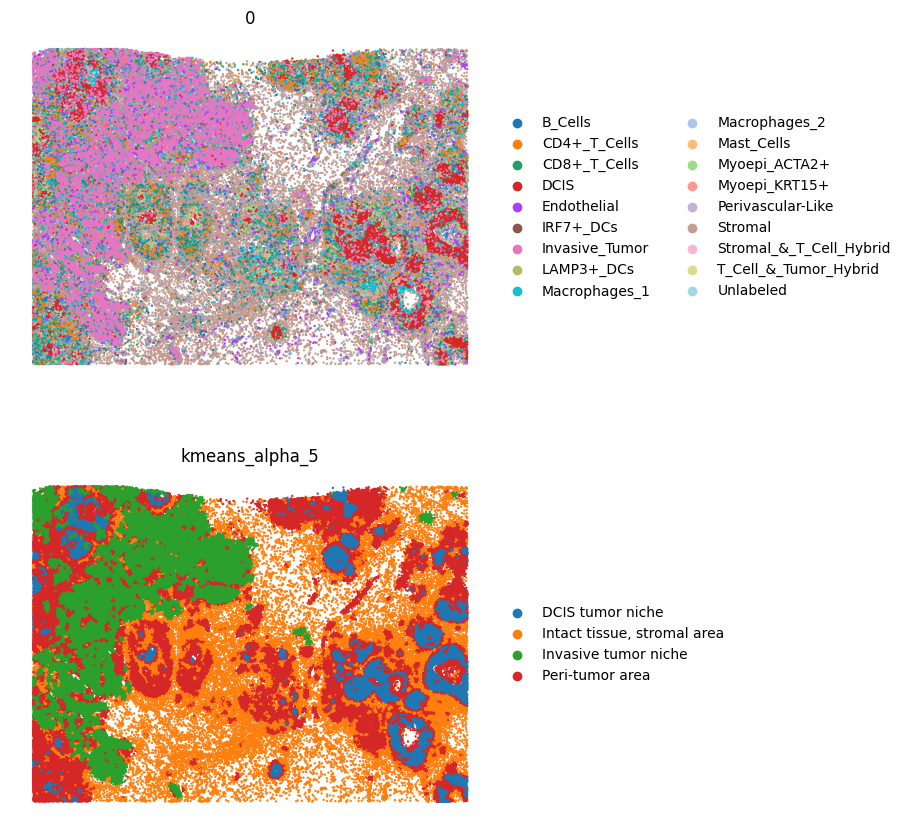

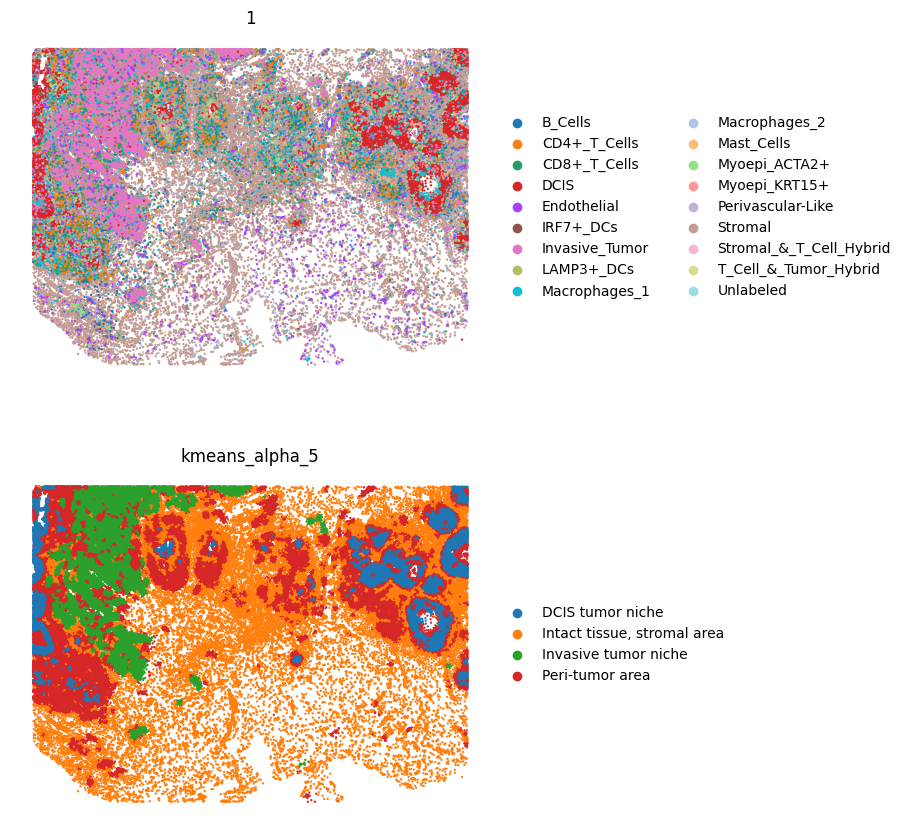

In [51]:
for sample in adata_proseg.obs[setup.SAMPLE].unique().tolist()[:]:
    # with plt.rc_context():
    sc.pl.spatial(
        adata_proseg[adata_proseg.obs[setup.SAMPLE] == sample],
        spot_size=40,
        # color=[setup.CELL_TYPE, setup.NICHE],
        color=[setup.NICHE],
        ncols=1,
        frameon=False,
        title=sample,
        cmap="Paired",
        show=False,
    )

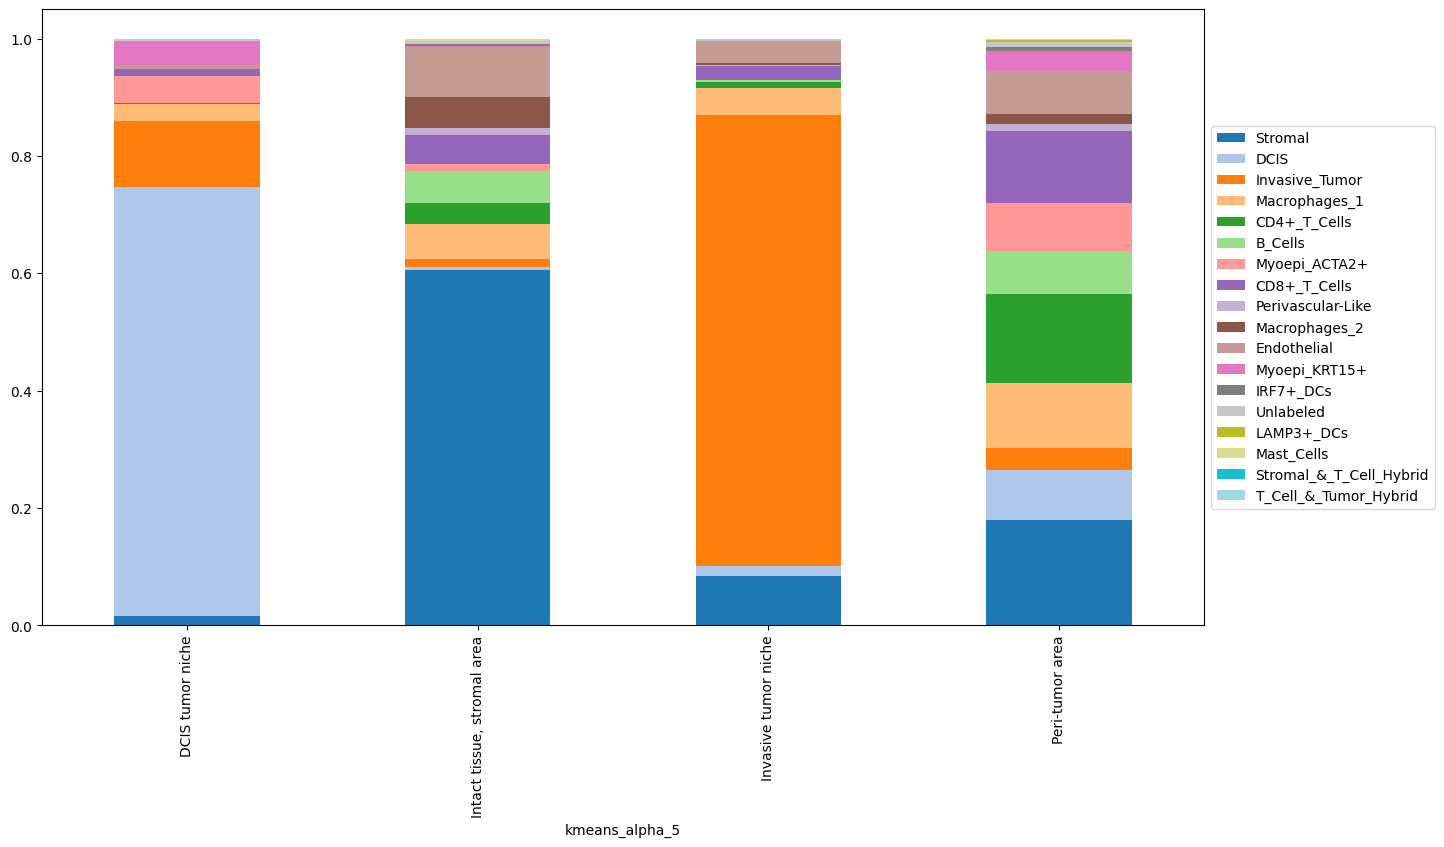

In [53]:
# take 'adata.obsm[neighborhood_composition'] and group by adata.obs["kmeans_alpha_5"] discrete values, then plot the mean of each group:
mean_prop_per_cluster = (
    adata_proseg.obsm["niche_composition"]
    .groupby(adata_proseg.obs["kmeans_alpha_4"])
    .mean()
)
mean_prop_per_cluster = (
    adata_proseg.obsm["niche_composition"]
    .groupby(adata_proseg.obs[setup.NICHE])
    .mean()
)


# okay so not a barplot but a bar that is the contribution of each cell type for each cluster

# put the legend outside the plot

mean_prop_per_cluster.plot.bar(stacked=True, figsize=(15, 8), cmap="tab20")

plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

In [45]:
adata_proseg

AnnData object with n_obs × n_vars = 278658 × 313
    obs: 'sample', '_scvi_batch', 'cell_type', '_scvi_labels', 'batch', 'predictions_scanvi', 'x', 'y', 'z', 'observed_x', 'observed_y', 'observed_z', 'fov', 'probability', 'background', 'confusion', 'n_counts', '_indices', '_scvi_ind_x', 'predicted_celltype_resolvi', 'predicted_celltype_prob_resolvi', 'predictions_resolvi_proseg', 'predictions_resolvi_proseg_coarse', 'predicted_celltype_resolvi_coarse', 'index', 'kmeans_alpha_4', 'kmeans_alpha_5'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'pca'
    obsm: 'X_pca', 'X_resolvi', 'X_resolvi_MDE', 'X_resolvi_proseg', 'X_scANVI', 'X_scANVI_MDE', 'X_spatial', 'celltype_transfer_resolvi', 'distance_neighbor', 'index_neighbor', 'observed_spatial', 'spatial', 'niche_indexes', 'niche_distances', 'niche_composition'
    varm: 'PCs'
    layers: 'counts', 'counts_wo_bg'

## Step 6: relabel CD4 and CD8 T cells

`predictions_resolvi_proseg_coarse_corrected` (the cell types used by the Proseg analysis) is `predictions_resolvi_proseg_coarse` with the CD4+ and CD8+ T cells relabelled from the two Leiden clusters (`leiden_nichevi_T`) of a scVIVA embedding of the T cells: 2,668 cells switched between CD4+ and CD8+ T cells, no other change.

The two cells below are the code that was used, kept commented out: they need `adata_T`, the T cells with their `leiden_nichevi_T` clusters, whose construction was not saved. The provided `proseg_resolvi_scanvi_xenium_breast_cancer_S1_R1_2.h5ad` already contains the result.

In [ ]:
# # Create a copy of the original cell type column
# adata_proseg.obs[f"{setup.CELL_TYPE}_corrected"] = adata_proseg.obs[setup.CELL_TYPE].copy()

# # Define the cluster to cell type mapping
# cluster_to_type = {
#     '0': "CD4+_T_Cells",
#     '1': "CD8+_T_Cells",
# }

# # Map the values in adata_T
# adata_T.obs["leiden_nichevi_T_mapped"] = adata_T.obs["leiden_nichevi_T"].map(cluster_to_type)

In [ ]:
# # Create a boolean mask for T cells in the main adata object
# t_cell_mask = adata_proseg.obs[setup.CELL_TYPE].isin(["CD4+_T_Cells", "CD8+_T_Cells"])

# # Ensure the index of adata_T matches the T cell subset of adata
# adata_T = adata_T[adata_T.obs.index.isin(adata_proseg.obs.index[t_cell_mask])]

# # Create a Series with the new labels
# new_labels = pd.Series(index=adata_proseg.obs.index, dtype='object')
# new_labels.loc[t_cell_mask] = adata_T.obs["leiden_nichevi_T_mapped"].values

# # Update the corrected cell types
# adata_proseg.obs[f"{setup.CELL_TYPE}_corrected"] = adata_proseg.obs[f"{setup.CELL_TYPE}_corrected"].astype('object')
# adata_proseg.obs.loc[~new_labels.isna(), f"{setup.CELL_TYPE}_corrected"] = new_labels[~new_labels.isna()]

# # # Convert back to categorical if needed
# # categories = np.unique(adata_proseg.obs[f"{setup.CELL_TYPE}_corrected"])
# # adata_proseg.obs[f"{setup.CELL_TYPE}_corrected"] = pd.Categorical(
# #     adata_proseg.obs[f"{setup.CELL_TYPE}_corrected"],
# #     categories=categories
# # )

# # Verify the changes
# print(adata_proseg.obs[f"{setup.CELL_TYPE}_corrected"].value_counts())
# print(adata_proseg.obs[setup.CELL_TYPE].value_counts())
# # print(adata_T.obs["leiden_nichevi_T_mapped"].value_counts())